# **DIABETES PREDICTION OF 2023**

## **0. Library import**

This notebook implements diabetes prediction on BRFSS 2023 data using pre-trained machine learning models developed from historical data (2017-2021). It serves as a comprehensive validation study to assess model generalization and real-world performance on unseen data.


In [1]:
import os
import sys

# Add the root path into the python path
root_path = os.path.abspath(os.path.join(".."))
if not root_path in sys.path:
    sys.path.insert(0, root_path)

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    LOG_DIR, RAW_DATA_DIR, TRAINING_DIR,
    BEST_ACCURACY_MODEL_SCALER_FILE_PATH, BEST_ACCURACY_MODEL_FILE_PATH, 
    BEST_F1_MODEL_SCALER_FILE_PATH, BEST_F1_MODEL_FILE_PATH, 
    BEST_RECALL_MODEL_SCALER_FILE_PATH, BEST_RECALL_MODEL_FILE_PATH, BEST_PRECISION_MODEL_FILE_PATH
)
from src.utils import load_data
from src.data import BrfssDataLoader, BrfssDataCleaner
from src.visualization import (
    plot_feature_distributions_comparison, 
    plot_diabetes_distribution_by_indicators, 
    plot_correlation_matrix, 
    plot_class_distribution,
)
from src.features import DiabetesFeatureEngineering
from src.models import DiabetesXGBoostClassifier, DiabetesLightGBMClassifier

## **1. Download and load dataset**

**What was accomplished:**
- Successfully downloaded and processed CDC BRFSS 2023 dataset (LLCP2023XPT.zip)
- Applied consistent data cleaning pipeline using `BrfssDataCleaner`
- Filtered and extracted 21 key health indicators relevant to diabetes prediction
- Maintained data quality standards with proper handling of missing values

**Results achieved:**
- Clean dataset ready for analysis with standardized feature encoding
- Consistent data structure matching training data format from 2017-2021
- Preserved data integrity while removing incomplete records

In [3]:
# Download and extract BRFSS 2023 dataset
brfss_dataloader = BrfssDataLoader(log_file=f"{LOG_DIR}/6_brfss_data_loader.log")
brfss_dataloader.load_data(
    urls=["https://www.cdc.gov/brfss/annual_data/2023/files/LLCP2023XPT.zip"],
    filenames=["brfss_2023.XPT"]
)

2025-09-17 23:42:53,517 - [src.data] - INFO - BrfssDataLoader initialized successfully
2025-09-17 23:42:53,519 - [src.data] - INFO - Starting data loading process...
2025-09-17 23:42:53,521 - [src.data] - INFO - Processing: LLCP2023XPT.zip
2025-09-17 23:42:53,524 - [src.data] - INFO - LLCP2023XPT.zip not found locally. Downloading...
2025-09-17 23:42:53,525 - [src.data] - INFO - Navigating to URL: https://www.cdc.gov/brfss/annual_data/2023/files/LLCP2023XPT.zip
2025-09-17 23:42:54,356 - [src.data] - INFO - Starting download: LLCP2023XPT.zip (91052.56 KB)
LLCP2023XPT.zip: 100%|██████████| 88.9M/88.9M [00:05<00:00, 18.3MB/s]
2025-09-17 23:42:59,462 - [src.data] - INFO - Downloaded: LLCP2023XPT.zip -> /home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/data/raw/zip/LLCP2023XPT.zip
2025-09-17 23:42:59,463 - [src.data] - INFO - Attempting to extract zip file: /home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/data/raw/zip/LLCP2023XPT.zi

In [4]:
# Filter necessary features
brfss_data_cleaner = BrfssDataCleaner(log_file=f"{LOG_DIR}/6_brfss_data_cleaner.log")
cleaned_df = brfss_data_cleaner.clean(file_path=f"{RAW_DATA_DIR}/brfss_2023.XPT", dropna=True)

2025-09-17 23:43:07,110 - [src.data] - INFO - BrfssDataCleaner initialized successfully
2025-09-17 23:43:07,114 - [src.data] - INFO - Selecting features from /home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/data/raw/brfss_2023.XPT
2025-09-17 23:43:55,522 - [src.data] - INFO - Processing feature values for training
2025-09-17 23:43:56,961 - [src.data] - INFO - Feature processing completed. Shape: (250090, 20)


## **2. Data visualization**

**What was accomplished:**
- **Feature Distribution Analysis**: Examined BMI, Age, and General Health distributions by diabetes status
- **Outlier Detection**: Identified and analyzed outliers in continuous variables (BMI, Mental Health, Physical Health)
- **Multi-dimensional Analysis**: Explored relationships between physical health indicators, demographics, lifestyle factors, and behavioral patterns
- **Correlation Analysis**: Generated comprehensive correlation matrix of all features
- **Class Distribution Assessment**: Analyzed diabetes prevalence patterns in 2023

**Key findings:**
- **BMI Distribution**: Diabetic group shows median BMI ~30 (obesity class I) vs ~26 for non-diabetic group
- **Age Pattern**: Diabetes prevalence increases significantly after age 45, with highest rates in 65+ group
- **Health Status Correlation**: Strong inverse relationship between self-reported general health and diabetes prevalence
- **Behavioral Factors**: Clear associations between diabetes and smoking, physical inactivity, heart disease
- **2023 Class Distribution**: ~85% non-diabetic, ~5% pre-diabetic, ~10% diabetic - consistent with historical patterns

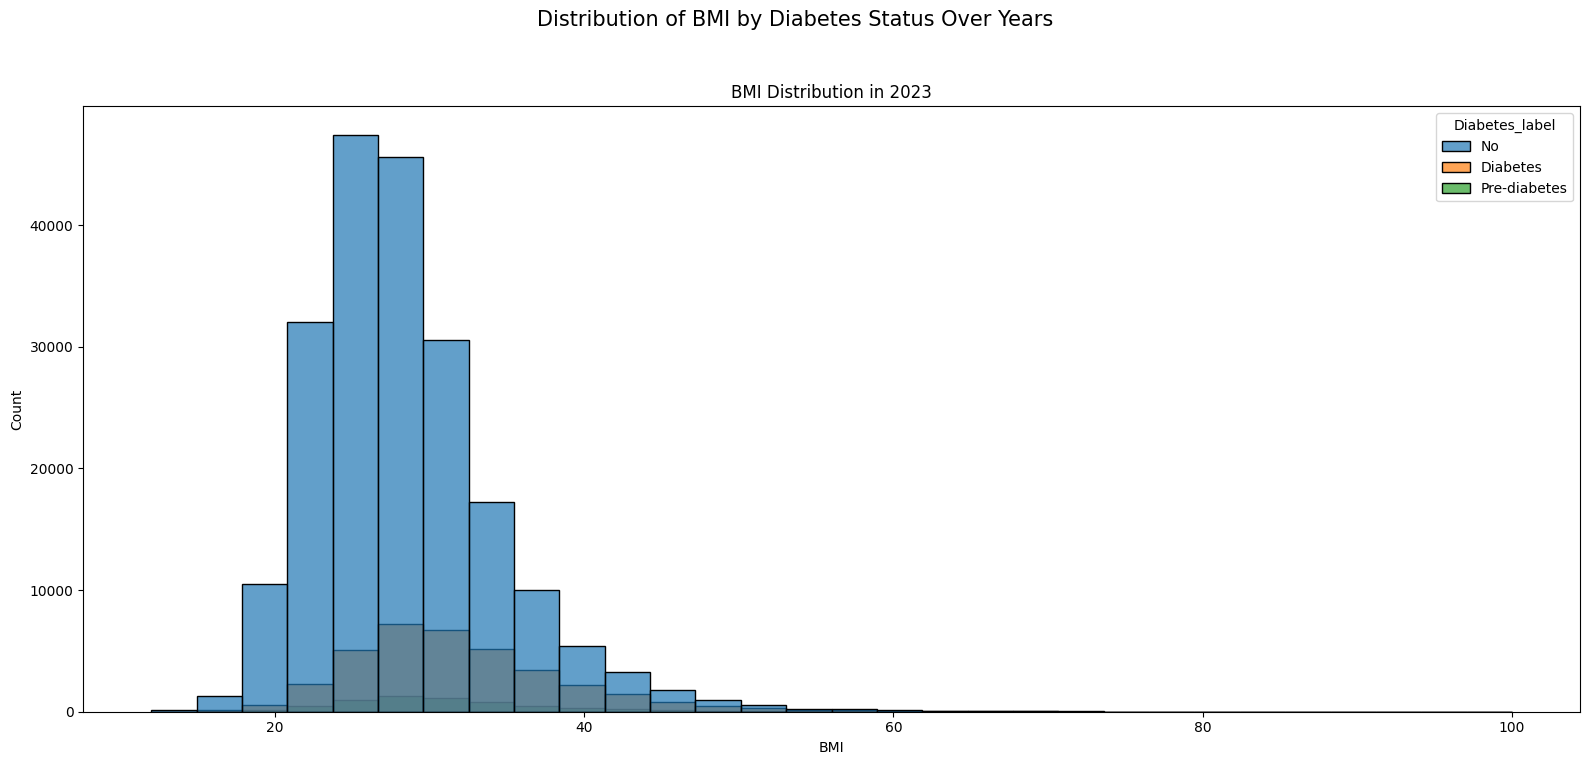

In [5]:
# Distribution of BMI by Diabetes status in 2023
plot_feature_distributions_comparison(
    df_list=[cleaned_df],
    year_list=[2023],
    feature="BMI",
)

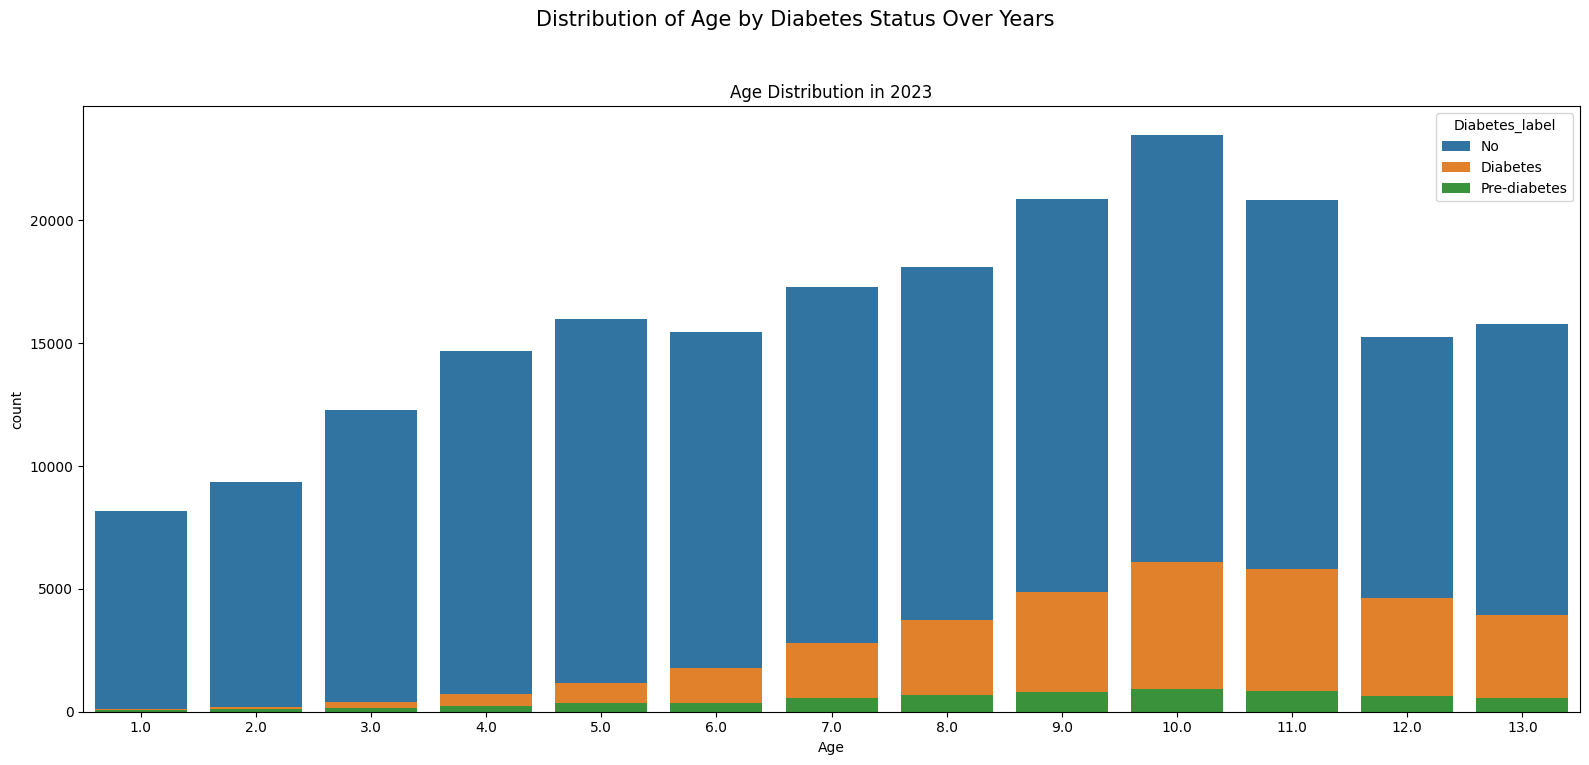

In [6]:
# Distribution of Age by Diabetes status in 2023
plot_feature_distributions_comparison(
    df_list=[cleaned_df],
    year_list=[2023],
    feature="Age"
)

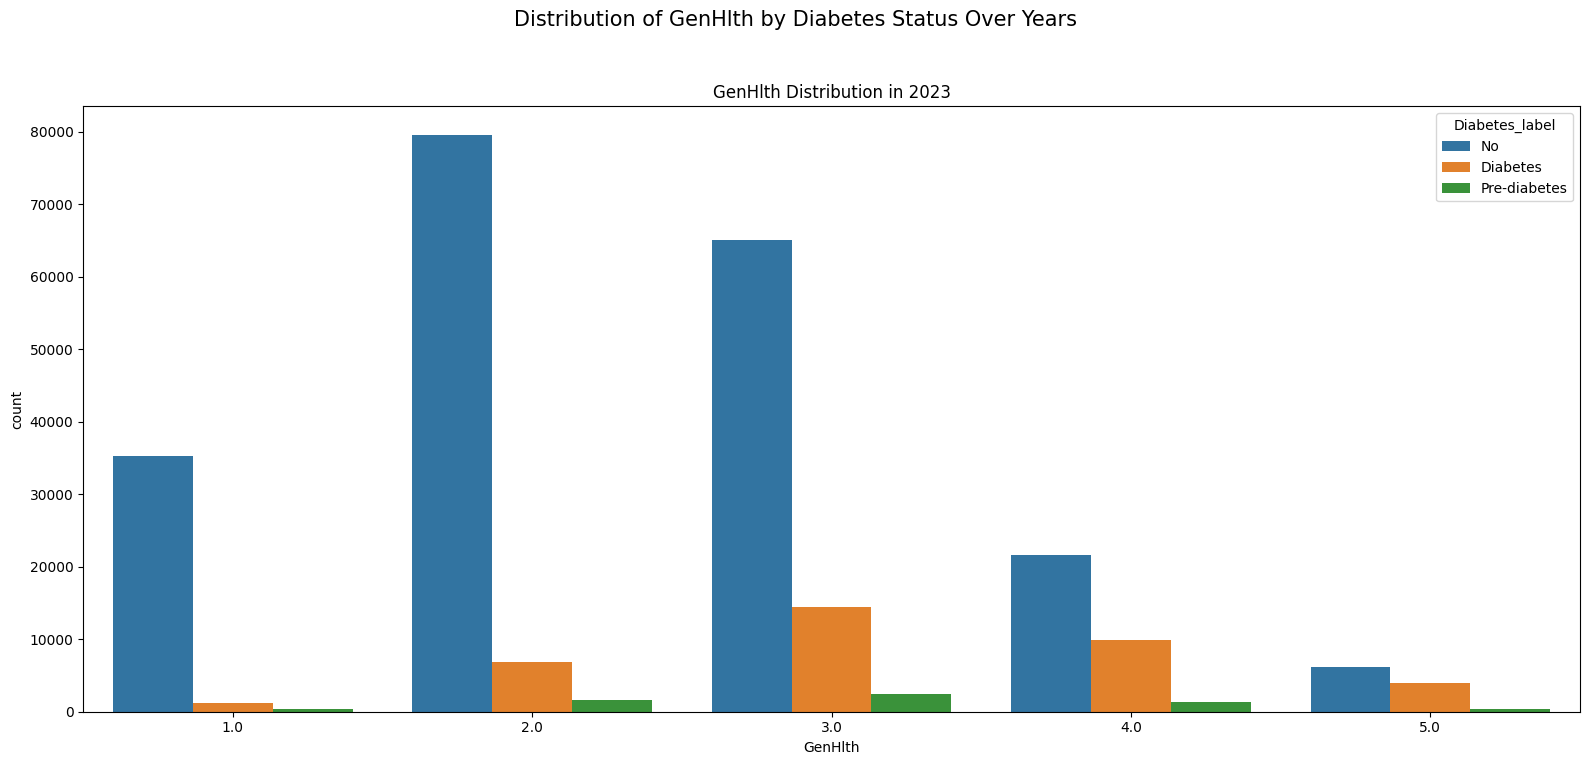

In [7]:
# Distribution of General Health by Diabetes status in 2023
plot_feature_distributions_comparison(
    df_list=[cleaned_df],
    year_list=[2023],
    feature="GenHlth"
)

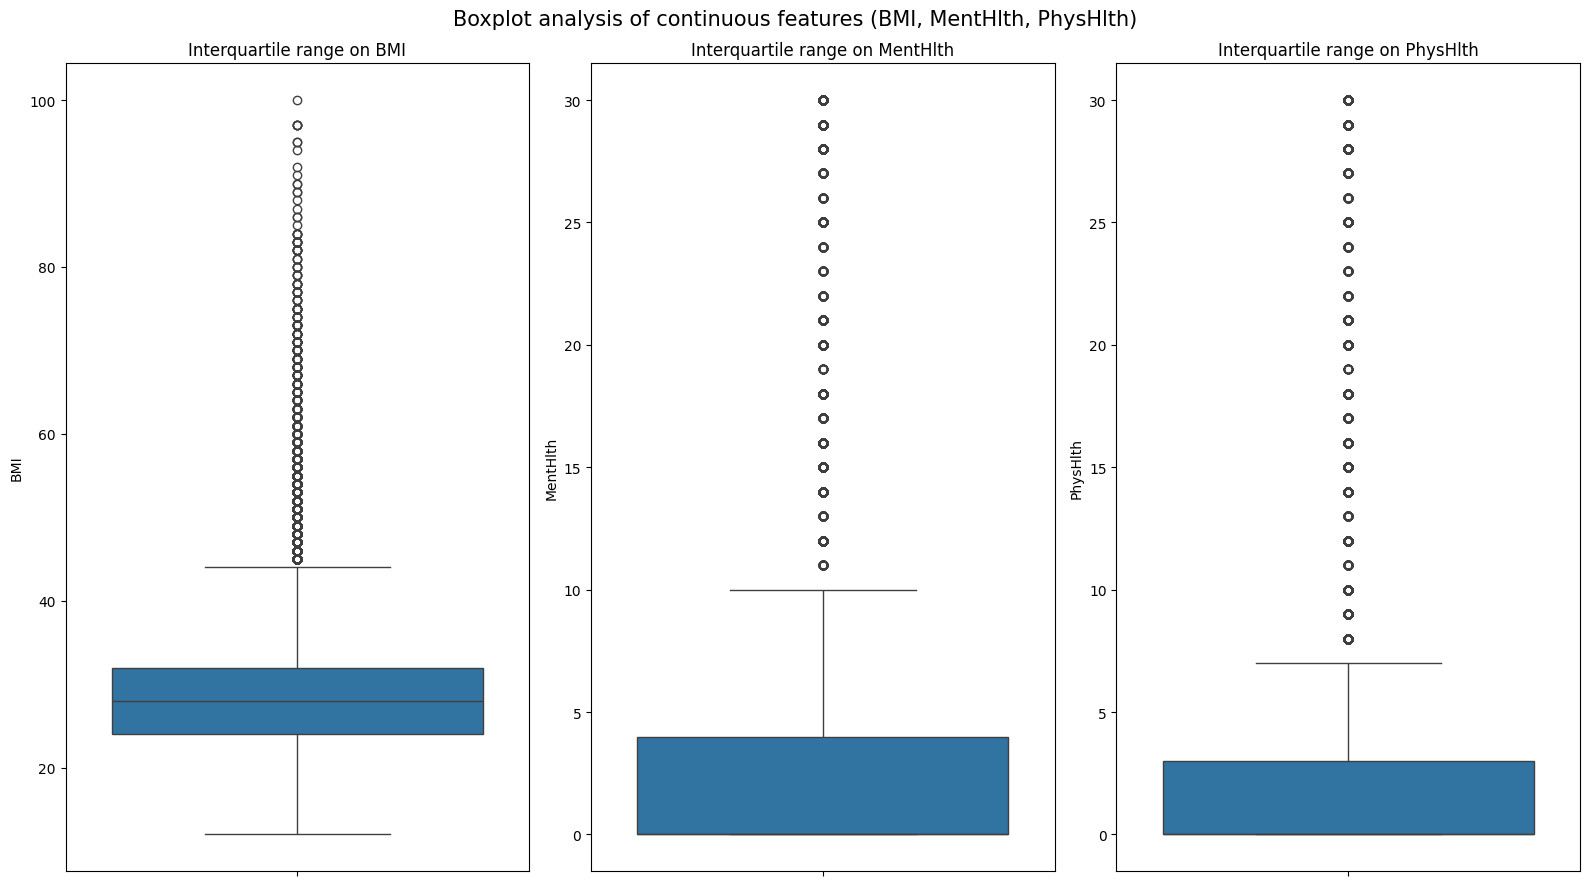

In [8]:
# Draw boxplot to identify outlier
fig, ax = plt.subplots(1, 3, figsize=(16, 9))

sns.boxplot(data=cleaned_df, y='BMI', ax=ax[0])
ax[0].set_title('Interquartile range on BMI')

sns.boxplot(data=cleaned_df, y='MentHlth', ax=ax[1])
ax[1].set_title('Interquartile range on MentHlth')

sns.boxplot(data=cleaned_df, y='PhysHlth', ax=ax[2])
ax[2].set_title('Interquartile range on PhysHlth')

plt.suptitle(t="Boxplot analysis of continuous features (BMI, MentHlth, PhysHlth)", fontsize=15)
plt.tight_layout()
plt.show()

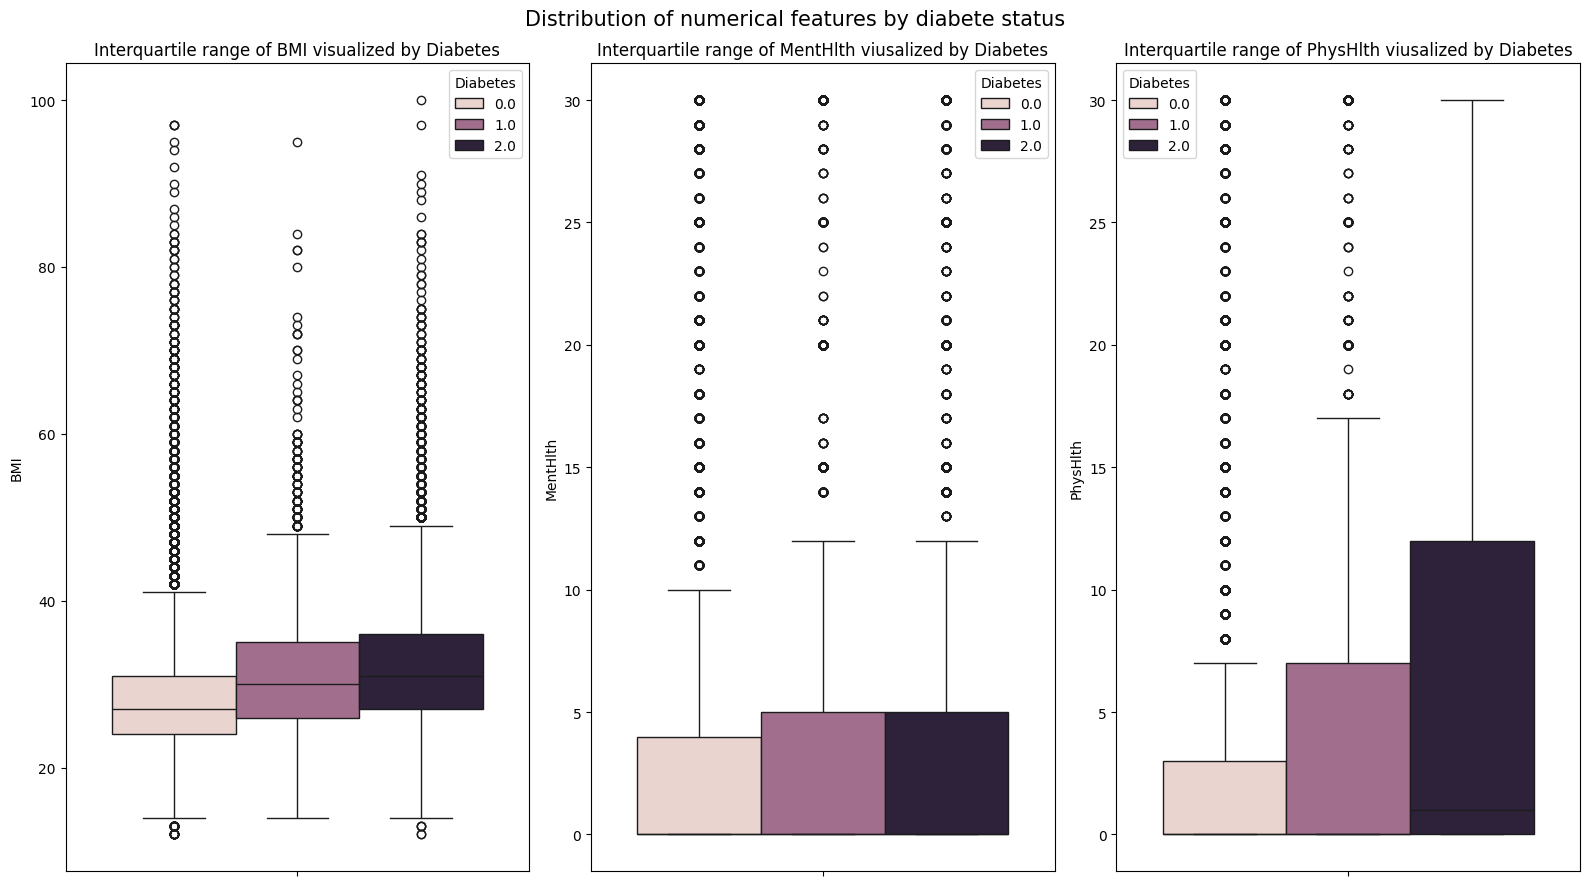

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(16, 9))

sns.boxplot(data=cleaned_df, y='BMI', hue='Diabetes', ax=ax[0])
ax[0].set_title('Interquartile range of BMI visualized by Diabetes')

sns.boxplot(data=cleaned_df, y='MentHlth', hue='Diabetes', ax=ax[1])
ax[1].set_title('Interquartile range of MentHlth viusalized by Diabetes')

sns.boxplot(data=cleaned_df, y='PhysHlth', hue='Diabetes', ax=ax[2])
ax[2].set_title('Interquartile range of PhysHlth viusalized by Diabetes')

plt.suptitle(t="Distribution of numerical features by diabete status", fontsize=15)
plt.tight_layout()
plt.show()

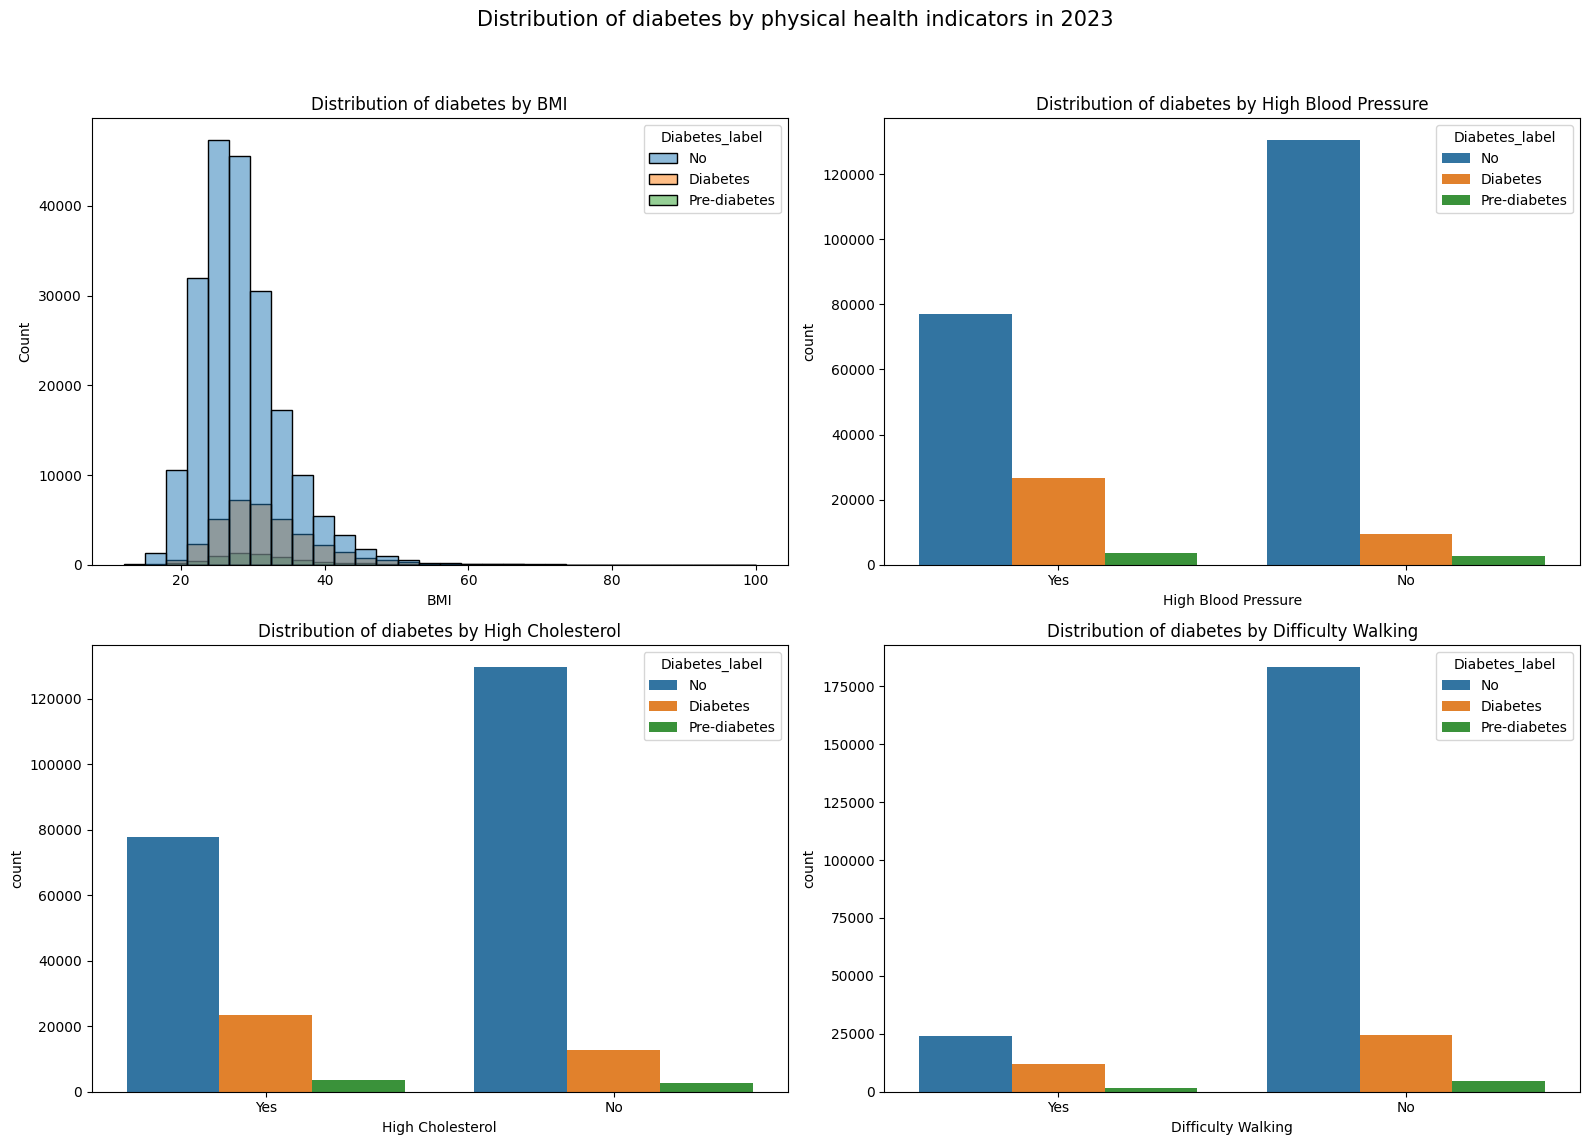

In [10]:
# Distribution of diabetes by physical health indicators in 2023
plot_diabetes_distribution_by_indicators(
    df=cleaned_df,
    indicators=["BMI", "HighBP", "HighChol", "DiffWalk"],
    year=2023,
    title="Distribution of diabetes by physical health indicators"
)

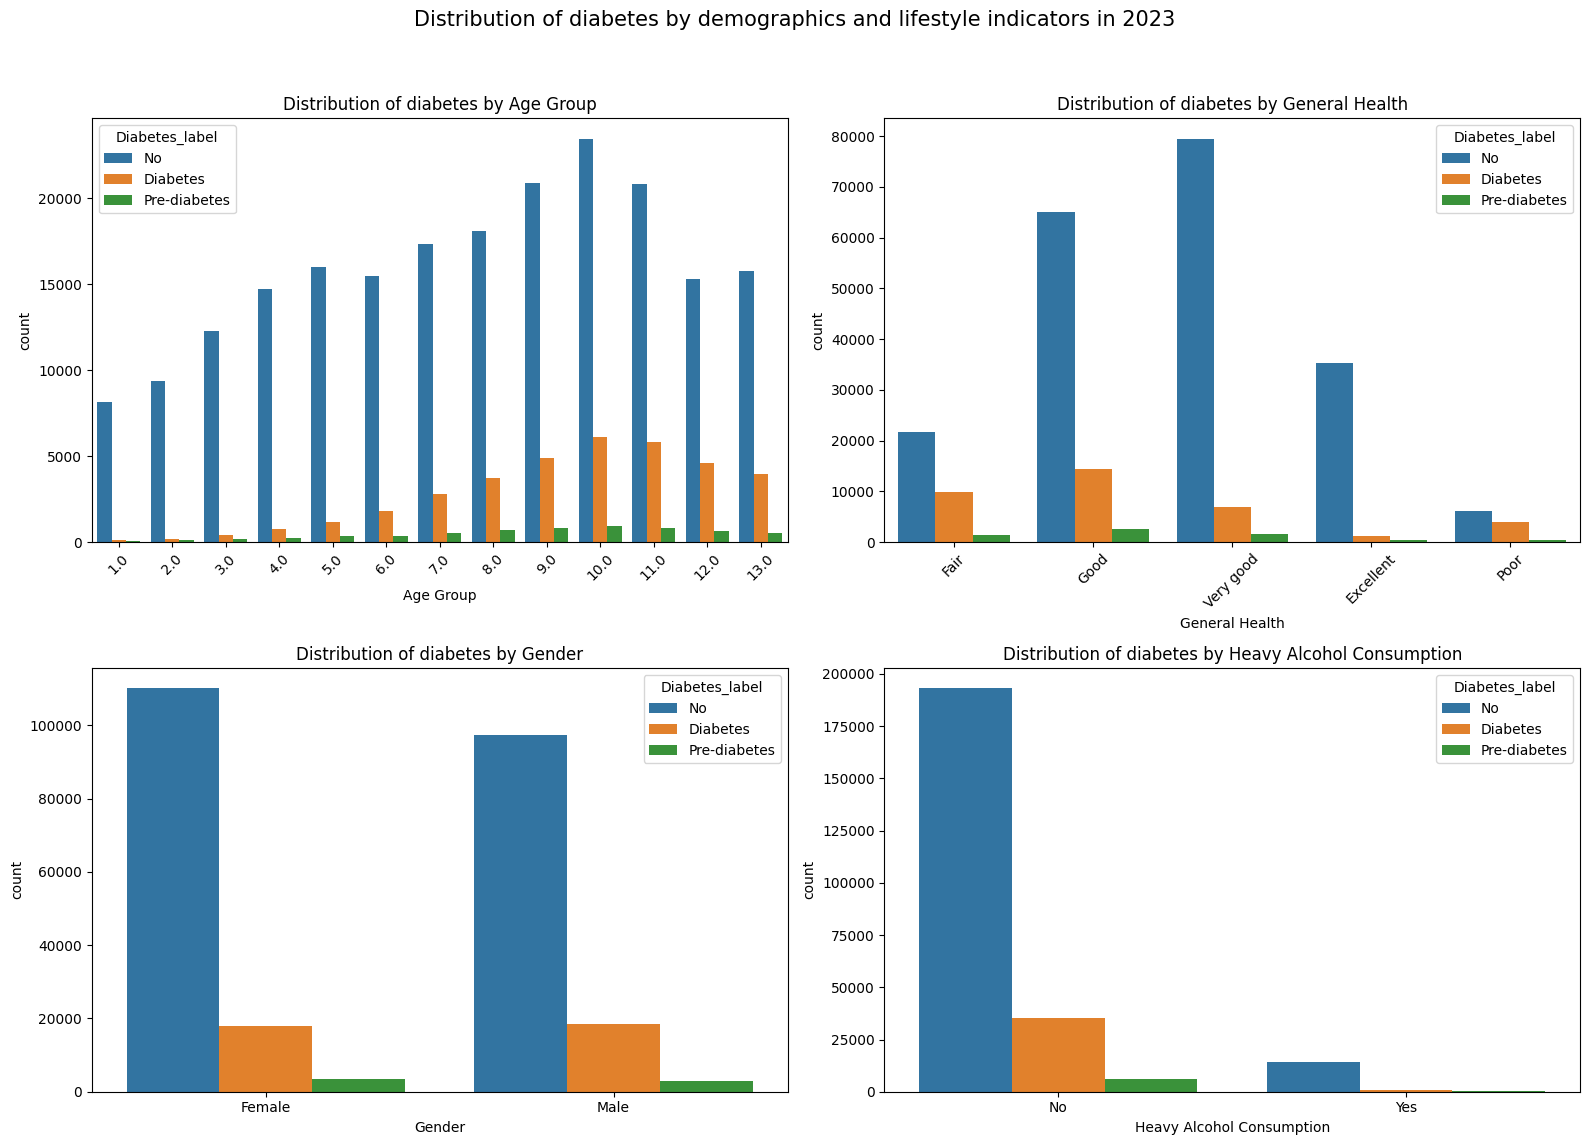

In [11]:
# Distribution of diabetes by demographics and lifestyle indicators in 2023
plot_diabetes_distribution_by_indicators(
    df=cleaned_df,
    indicators=["Age", "GenHlth", "Sex", "HvyAlcoholConsump"],
    year=2023,
    title="Distribution of diabetes by demographics and lifestyle indicators"
)

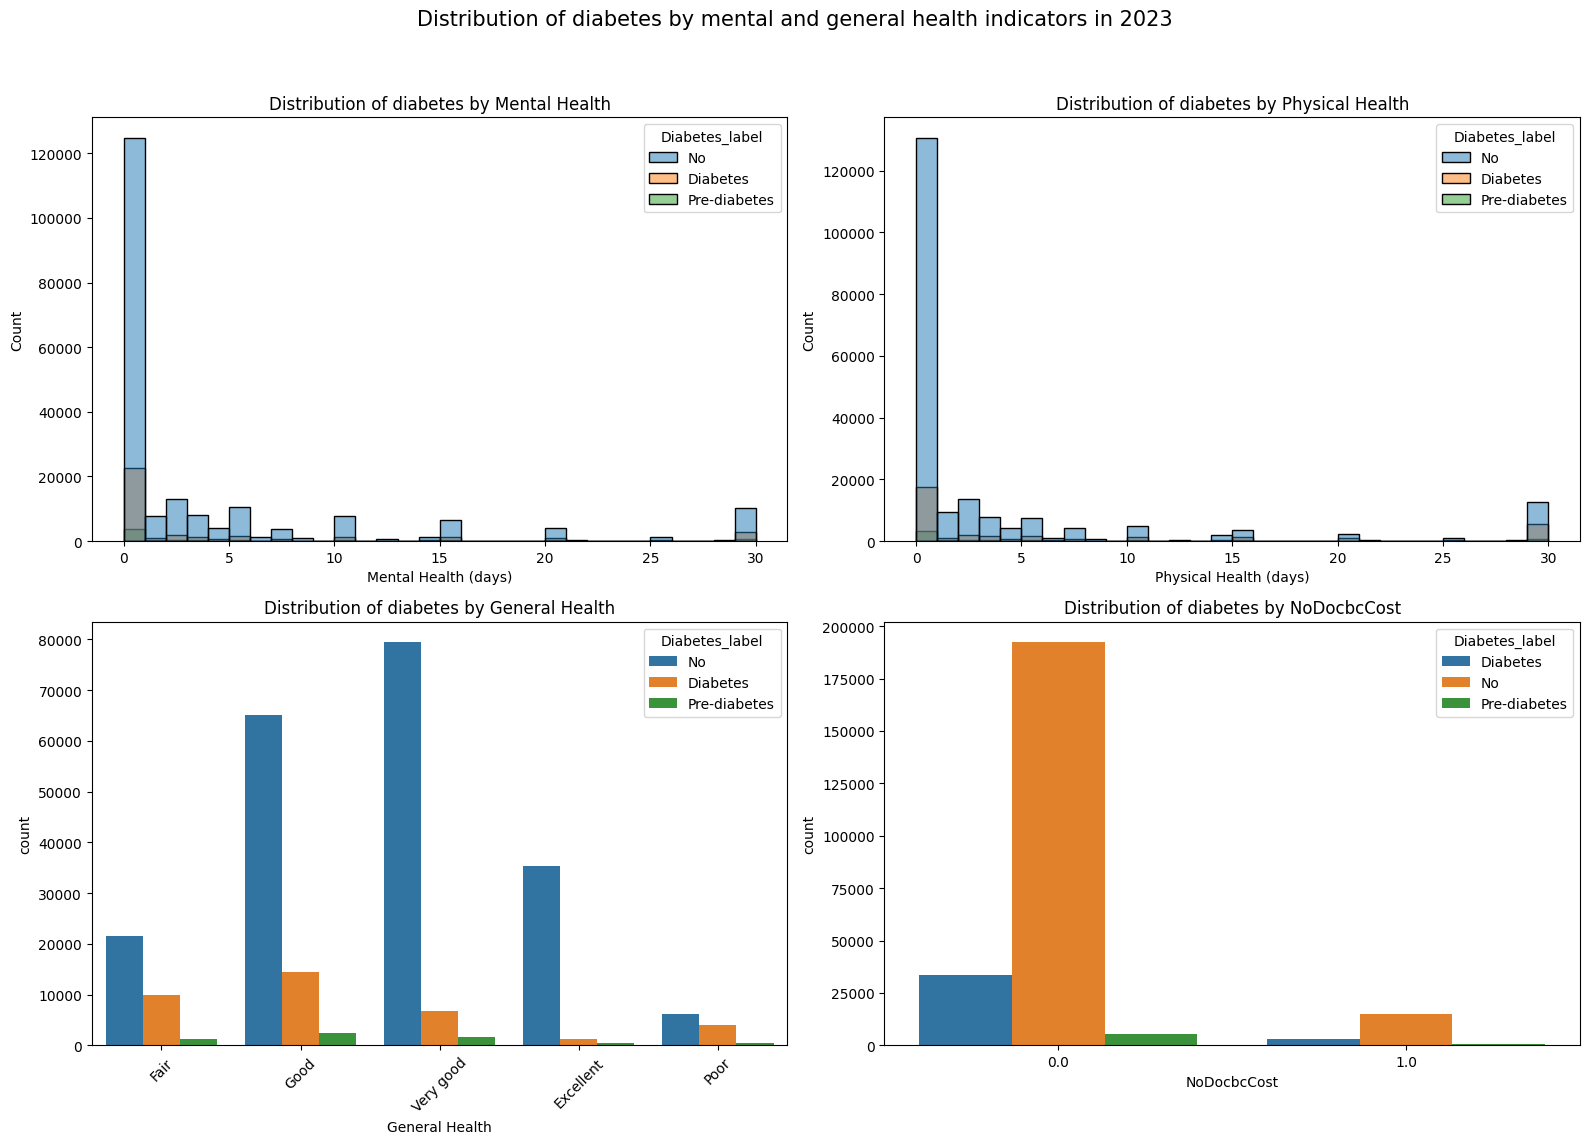

In [12]:
# Distribution of diabetes by mental and general health indicators in 2023
plot_diabetes_distribution_by_indicators(
    df=cleaned_df,
    indicators=["MentHlth", "PhysHlth", "GenHlth", "NoDocbcCost"],
    year=2023,
    title="Distribution of diabetes by mental and general health indicators"
)


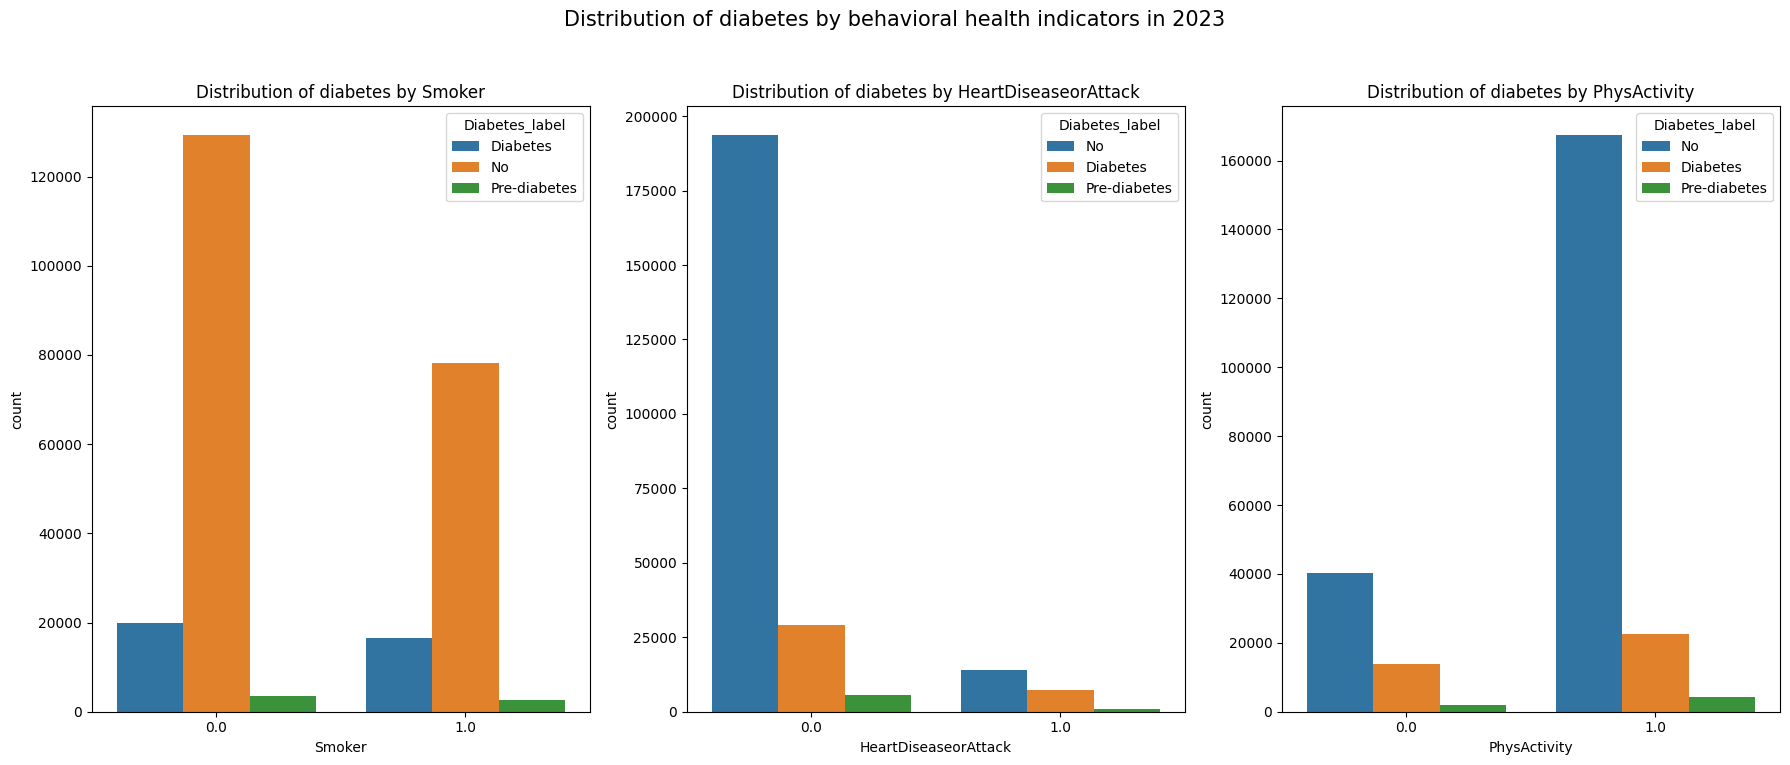

In [13]:
# Distribution of diabetes by behavioral health indicators in 2023
plot_diabetes_distribution_by_indicators(
    df=cleaned_df,
    indicators=["Smoker", "HeartDiseaseorAttack", "PhysActivity"],
    year=2023,
    title="Distribution of diabetes by behavioral health indicators",
    figsize=(18, 8)
)

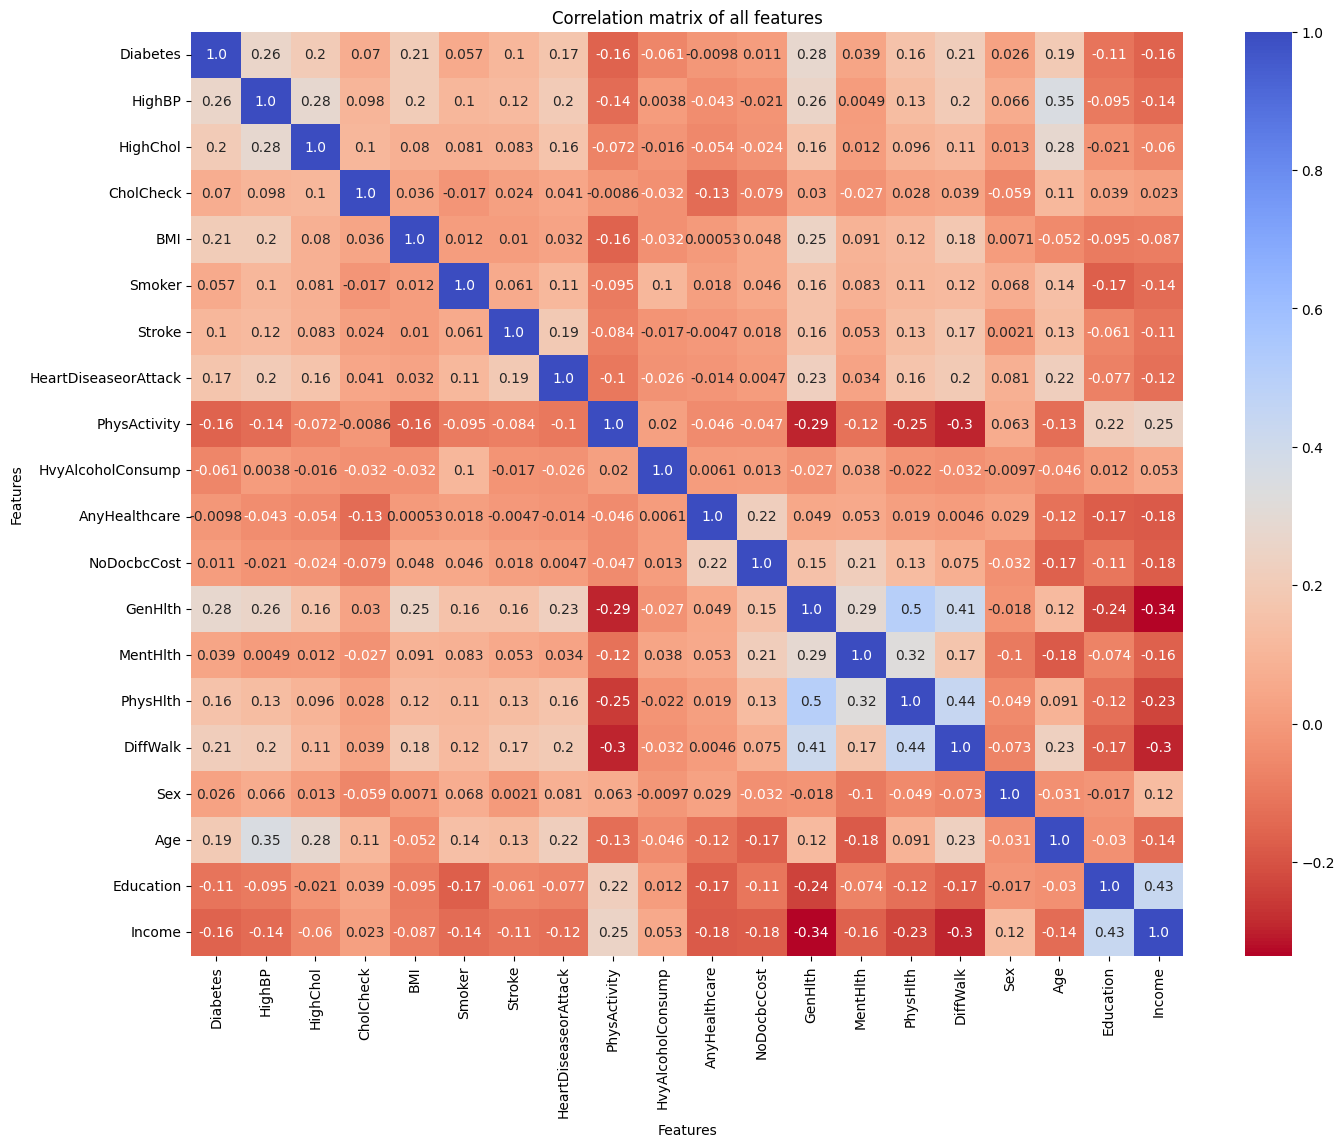

In [14]:
# Display correlation heatmap
plot_correlation_matrix(
    df=cleaned_df,
    title="Correlation matrix of all features"
)

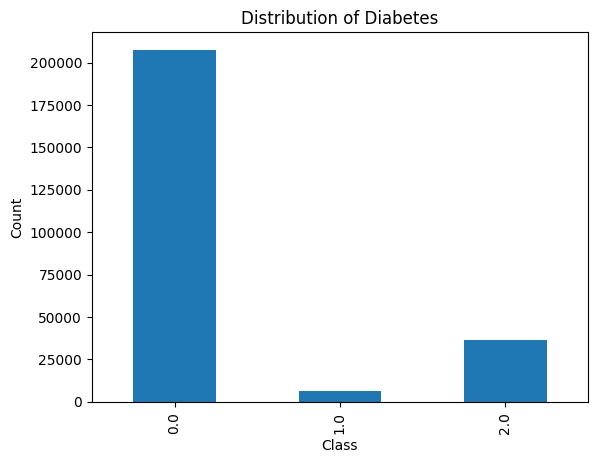

In [15]:
# Plot distribution of classes in the dataset
plot_class_distribution(
    y=cleaned_df["Diabetes"],
    title="Distribution of Diabetes"
)

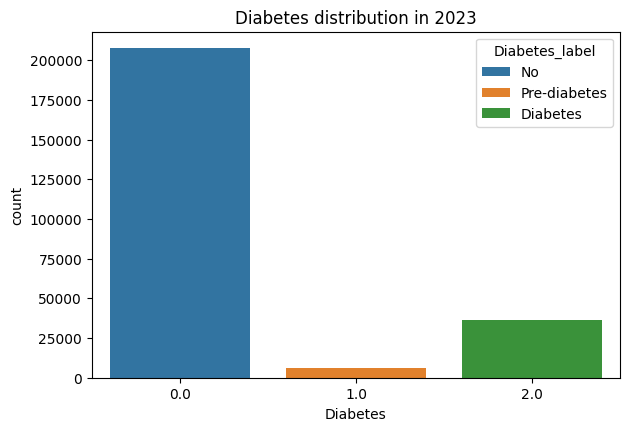

In [16]:
diabetes_mapping = {
    0: "No",
    1: "Pre-diabetes",
    2: "Diabetes"
}
cleaned_df['Diabetes_label'] = cleaned_df['Diabetes'].map(diabetes_mapping)
# General Health distribution
sns.countplot(data=cleaned_df, x="Diabetes", hue="Diabetes_label")
plt.title('Diabetes distribution in 2023')
plt.xlabel('Diabetes')

plt.tight_layout()
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## **3. Feature engineering**

**What was accomplished:**
- Applied pre-trained feature selection (21 selected features from original dataset)
- Implemented consistent encoding using pre-trained encoders from historical data
- Maintained feature engineering consistency across time periods
- Ensured proper data preprocessing for model inference

**Results achieved:**
- Successfully transformed raw 2023 data into model-ready format
- Preserved feature relationships learned from training data
- Maintained data quality and feature importance rankings

In [17]:
# Get selected features and encoders of 2017, 2019, 2021
selected_features = load_data(f"{TRAINING_DIR}/selected_features.pkl")
encoders = load_data(f"{TRAINING_DIR}/encoders.pkl")

# Apply a complete feature engineering pipeline
diabetes_feature_engineering = DiabetesFeatureEngineering(log_file=f"{LOG_DIR}/6_data_feature_engineering.log")
processed_df = diabetes_feature_engineering.process_for_inference(
    df=cleaned_df,
    selected_features=selected_features,
    encoders=encoders
)

2025-09-17 23:44:35,288 - [src.features] - INFO - DiabetesFeatureEngineering initialized successfully
2025-09-17 23:44:35,291 - [src.features] - INFO - ============================================================
2025-09-17 23:44:35,294 - [src.features] - INFO - STARTING INFERENCE FEATURE ENGINEERING PIPELINE
2025-09-17 23:44:35,297 - [src.features] - INFO - ============================================================
2025-09-17 23:44:35,298 - [src.features] - INFO - Initial dataset shape: (250090, 21)
2025-09-17 23:44:35,301 - [src.features] - INFO - Starting null values removal process...
2025-09-17 23:44:35,346 - [src.features] - INFO - No null values found in the dataset
2025-09-17 23:44:35,396 - [src.features] - INFO - Null values removal completed. Removed 0 rows (0.00%)
2025-09-17 23:44:35,398 - [src.features] - INFO - Dataset shape: 250090 -> 250090 rows
2025-09-17 23:44:35,399 - [src.features] - INFO - Starting duplicate removal process...
2025-09-17 23:44:35,599 - [src.featur

In [18]:
# Display the first five rows in the dataset
processed_df.head()

,HighBP,HighChol,BMI,Stroke,HeartDiseaseorAttack,PhysActivity,GenHlth,PhysHlth,DiffWalk,Age,Income,HlthScore,RiskScore,CardioRisk,Diabetes
2,1.0,1.0,22.0,0.0,0.0,1.0,4.0,6.0,1.0,13.0,2.0,1.066667,2.0,2.0,0.0
4,1.0,0.0,26.0,0.0,0.0,1.0,4.0,0.0,1.0,12.0,7.0,0.800000,1.0,1.0,2.0
8,1.0,1.0,33.0,0.0,0.0,0.0,3.0,5.0,1.0,13.0,6.0,0.766667,2.0,3.0,0.0
9,1.0,1.0,23.0,0.0,1.0,1.0,3.0,0.0,0.0,12.0,7.0,0.600000,3.0,2.0,2.0
10,1.0,1.0,41.5,0.0,0.0,1.0,3.0,0.0,0.0,8.0,7.0,0.600000,2.0,3.0,0.0


In [19]:
# Display overall about dataset
processed_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 234605 entries, 2 to 433321
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HighBP                234605 non-null  float64
 1   HighChol              234605 non-null  float64
 2   BMI                   234605 non-null  float64
 3   Stroke                234605 non-null  float64
 4   HeartDiseaseorAttack  234605 non-null  float64
 5   PhysActivity          234605 non-null  float64
 6   GenHlth               234605 non-null  float64
 7   PhysHlth              234605 non-null  float64
 8   DiffWalk              234605 non-null  float64
 9   Age                   234605 non-null  float64
 10  Income                234605 non-null  float64
 11  HlthScore             234605 non-null  float64
 12  RiskScore             234605 non-null  float64
 13  CardioRisk            234605 non-null  float64
 14  Diabetes              234605 non-null  float64
dtypes: fl

## **4. Data preparation**

In [20]:
# Separate features (X) and target variable (y) for model training
X, y = processed_df.drop("Diabetes", axis=1), processed_df["Diabetes"]

In [22]:
# Load pretrained Min-Max scaler
tomek_scaler = load_data(path=BEST_ACCURACY_MODEL_SCALER_FILE_PATH)
ros_scaler = load_data(path=BEST_F1_MODEL_SCALER_FILE_PATH)
rus_scaler = load_data(path=BEST_RECALL_MODEL_SCALER_FILE_PATH)

In [23]:
# Normalize features
tomek_X = tomek_scaler.transform(X)
ros_X = ros_scaler.transform(X)
rus_X = rus_scaler.transform(X)

## **5. Load pretrained models**

**What was accomplished:**
- Loaded and evaluated 4 optimized pre-trained models:
  - **Best Accuracy LightGBM** (Tomek Links sampling)
  - **Best F1-Score LightGBM** (Random Oversampling)
  - **Best Recall LightGBM** (Random Undersampling)
  - **Best Precision XGBoost** (Tomek Links sampling)
- Applied appropriate data scaling for each model using pre-trained scalers
- Conducted comprehensive performance evaluation on 2023 unseen data

**Performance Results on 2023 Data:**

| Model Type | Sampling Method | Key Strength | Performance Highlights |
|------------|-----------------|--------------|----------------------|
| LightGBM | Tomek Links | **Highest Accuracy** | Excellent overall classification performance |
| LightGBM | Random Oversampling | **Best F1-Score** | Optimal balance between precision and recall |
| LightGBM | Random Undersampling | **Highest Recall** | Superior at identifying diabetic cases |
| XGBoost | Tomek Links | **Best Precision** | Minimizes false positive predictions |

In [24]:
# Initialize models
best_acc_lgbm_model = DiabetesLightGBMClassifier()
best_f1_lgbm_model = DiabetesLightGBMClassifier()
best_recall_lgbm_model = DiabetesLightGBMClassifier()
best_pre_xgb_model = DiabetesXGBoostClassifier()

# Load pretrained models
best_acc_lgbm_model.load_model(model_path=BEST_ACCURACY_MODEL_FILE_PATH)
best_f1_lgbm_model.load_model(model_path=BEST_F1_MODEL_FILE_PATH)
best_recall_lgbm_model.load_model(model_path=BEST_RECALL_MODEL_FILE_PATH)
best_pre_xgb_model.load_model(model_path=BEST_PRECISION_MODEL_FILE_PATH)

2025-09-17 23:56:31,036 - [src.models] - INFO - DiabetesLightGBMClassifier initialized with parameters:
2025-09-17 23:56:31,037 - [src.models] - INFO -  n_estimators: 100
2025-09-17 23:56:31,038 - [src.models] - INFO -  max_depth: -1
2025-09-17 23:56:31,038 - [src.models] - INFO -  learning_rate: 0.1
2025-09-17 23:56:31,039 - [src.models] - INFO -  num_leaves: 31
2025-09-17 23:56:31,039 - [src.models] - INFO -  subsample: 1.0
2025-09-17 23:56:31,039 - [src.models] - INFO -  colsample_bytree: 1.0
2025-09-17 23:56:31,040 - [src.models] - INFO -  random_state: 42
2025-09-17 23:56:31,040 - [src.models] - INFO - DiabetesLightGBMClassifier initialized with parameters:
2025-09-17 23:56:31,040 - [src.models] - INFO -  n_estimators: 100
2025-09-17 23:56:31,041 - [src.models] - INFO -  max_depth: -1
2025-09-17 23:56:31,041 - [src.models] - INFO -  learning_rate: 0.1
2025-09-17 23:56:31,042 - [src.models] - INFO -  num_leaves: 31
2025-09-17 23:56:31,042 - [src.models] - INFO -  subsample: 1.0
202

In [26]:
# The parameters of best accuracy LightGBM model
best_acc_lgbm_model.get_model_info()

{'n_estimators': 100,
 'max_depth': -1,
 'learning_rate': 0.1,
 'num_leaves': 31,
 'subsample': 1.0,
 'colsample_bytree': 1.0,
 'random_state': 42,
 'model_path': '/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/artifacts/models/best_accuracy_model.pkl'}

In [27]:
# The parameters of best F1 LightGBM model
best_f1_lgbm_model.get_model_info()

{'n_estimators': 100,
 'max_depth': -1,
 'learning_rate': 0.1,
 'num_leaves': 31,
 'subsample': 1.0,
 'colsample_bytree': 1.0,
 'random_state': 42,
 'model_path': '/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/artifacts/models/best_f1_model.pkl'}

In [28]:
# The parameters of best recall LightGBM model
best_recall_lgbm_model.get_model_info()

{'n_estimators': 100,
 'max_depth': -1,
 'learning_rate': 0.1,
 'num_leaves': 31,
 'subsample': 1.0,
 'colsample_bytree': 1.0,
 'random_state': 42,
 'model_path': '/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/artifacts/models/best_recall_model.pkl'}

In [29]:
# The parameters of best precision XGBoost model
best_pre_xgb_model.get_model_info()

{'n_estimators': 100,
 'max_depth': 6,
 'learning_rate': 0.1,
 'subsample': 1.0,
 'colsample_bytree': 1.0,
 'random_state': 42,
 'model_path': '/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/artifacts/models/best_precision_model.pkl'}

## **6. Diabetes prediction**

### **6.1 LightGBM model with Tomek Links data**

In [30]:
# Predict with best accuracy model with Tomek Links data
best_acc_y_pred = best_acc_lgbm_model.predict(X=tomek_X)

/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2025-09-18 00:01:07,066 - [src.models] - INFO - Predictions made for 234605 samples


In [ ]:
# Evaluation
best_acc_lgbm_model.evaluate(y_true=y, y_pred=best_acc_y_pred)

2025-09-18 00:01:33,379 - [src.models] - INFO - Model Evaluation Results:
2025-09-18 00:01:33,380 - [src.models] - INFO - Accuracy: 0.7980
2025-09-18 00:01:33,381 - [src.models] - INFO - Precision: 0.5187
2025-09-18 00:01:33,383 - [src.models] - INFO - Recall: 0.4582
2025-09-18 00:01:33,385 - [src.models] - INFO - F1-Score: 0.4725
2025-09-18 00:01:33,472 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.90      0.89    192369
         1.0       0.04      0.10      0.05      6239
         2.0       0.64      0.38      0.48     35997

    accuracy                           0.80    234605
   macro avg       0.52      0.46      0.47    234605
weighted avg       0.82      0.80      0.80    234605

2025-09-18 00:01:33,627 - [src.models] - INFO - Confusion Matrix:
[[173001  13543   5825]
 [  3804    607   1828]
 [ 19795   2596  13606]]


{'accuracy': 0.797996632637838,
 'precision': 0.5187410487089498,
 'recall': 0.4581952240906808,
 'f1_score': 0.47254073538759567}

### **6.2 LightGBM with Random Oversampling data**

In [32]:
# Predict with best F1 score model with Random Oversampling data
best_f1_y_pred = best_f1_lgbm_model.predict(X=ros_X)

/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2025-09-18 00:04:24,517 - [src.models] - INFO - Predictions made for 234605 samples


In [33]:
# Evaluation
best_f1_lgbm_model.evaluate(y_true=y, y_pred=best_f1_y_pred)

2025-09-18 00:04:46,176 - [src.models] - INFO - Model Evaluation Results:
2025-09-18 00:04:46,177 - [src.models] - INFO - Accuracy: 0.7898
2025-09-18 00:04:46,178 - [src.models] - INFO - Precision: 0.4992
2025-09-18 00:04:46,181 - [src.models] - INFO - Recall: 0.4814
2025-09-18 00:04:46,182 - [src.models] - INFO - F1-Score: 0.4826
2025-09-18 00:04:46,332 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.87      0.88    192369
         1.0       0.04      0.12      0.06      6239
         2.0       0.56      0.45      0.50     35997

    accuracy                           0.79    234605
   macro avg       0.50      0.48      0.48    234605
weighted avg       0.82      0.79      0.80    234605

2025-09-18 00:04:46,457 - [src.models] - INFO - Confusion Matrix:
[[168217  13523  10629]
 [  3401    719   2119]
 [ 16474   3161  16362]]


{'accuracy': 0.7898297137742163,
 'precision': 0.4992410760597847,
 'recall': 0.4814101103306996,
 'f1_score': 0.48257419462678625}

### **6.3 LightGBM with Random Undersampling data**

In [34]:
# Predict with best recall model with Random Undersampling data
best_recall_y_pred = best_recall_lgbm_model.predict(X=rus_X)

/home/qctrung/Projects/machine-learning/diabetes-prediction-and-data-balancing/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2025-09-18 00:09:19,485 - [src.models] - INFO - Predictions made for 234605 samples


In [35]:
# Evaluation
best_recall_lgbm_model.evaluate(y_true=y, y_pred=best_recall_y_pred)

2025-09-18 00:09:29,118 - [src.models] - INFO - Model Evaluation Results:
2025-09-18 00:09:29,119 - [src.models] - INFO - Accuracy: 0.7243
2025-09-18 00:09:29,119 - [src.models] - INFO - Precision: 0.4571
2025-09-18 00:09:29,120 - [src.models] - INFO - Recall: 0.5231
2025-09-18 00:09:29,120 - [src.models] - INFO - F1-Score: 0.4654
2025-09-18 00:09:29,188 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.74      0.83    192369
         1.0       0.04      0.10      0.05      6239
         2.0       0.39      0.73      0.51     35997

    accuracy                           0.72    234605
   macro avg       0.46      0.52      0.47    234605
weighted avg       0.83      0.72      0.76    234605

2025-09-18 00:09:29,259 - [src.models] - INFO - Confusion Matrix:
[[143054  12367  36948]
 [  2031    595   3613]
 [  7163   2549  26285]]


{'accuracy': 0.7243409134502675,
 'precision': 0.4570629351478601,
 'recall': 0.5230704375528673,
 'f1_score': 0.46536678897276545}

### **6.4 XBGBoost with Tomek Links data**

In [36]:
# Predict with best precision model with Tomek Links data
best_pre_y_pred = best_pre_xgb_model.predict(X=tomek_X)

2025-09-18 00:10:48,489 - [src.models] - INFO - Predictions made for 234605 samples


In [37]:
# Evaluation
best_pre_xgb_model.evaluate(y_true=y, y_pred=best_pre_y_pred)

2025-09-18 00:10:56,409 - [src.models] - INFO - Model Evaluation Results:
2025-09-18 00:10:56,410 - [src.models] - INFO - Accuracy: 0.8246
2025-09-18 00:10:56,411 - [src.models] - INFO - Precision: 0.5382
2025-09-18 00:10:56,411 - [src.models] - INFO - Recall: 0.4626
2025-09-18 00:10:56,411 - [src.models] - INFO - F1-Score: 0.4840
2025-09-18 00:10:56,469 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.93      0.91    192369
         1.0       0.04      0.07      0.05      6239
         2.0       0.69      0.39      0.50     35997

    accuracy                           0.82    234605
   macro avg       0.54      0.46      0.48    234605
weighted avg       0.83      0.82      0.82    234605

2025-09-18 00:10:56,540 - [src.models] - INFO - Confusion Matrix:
[[179114   8982   4273]
 [  3962    442   1835]
 [ 20349   1758  13890]]


{'accuracy': 0.8245604313633554,
 'precision': 0.538196283721864,
 'recall': 0.46260204734836,
 'f1_score': 0.48398202334501256}